In [1]:
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython import display
import matplotlib.pyplot as plt
import pandas as pd
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec

# Exercise 09.1

## Code implementation

### Coordinates object
I implemented an object coordinates as a dictionary which univocally relate the generated cities to an index and perform the basic operation of computing the distance between two cities given the corresponding indexes both with metric L1 and L2.

Below is reported a summarized version of the header.

```C++
class coordinates
{
    public:
        coordinates();

        void initialize(string inputfile="input.dat");

        /*return the coordinates corresponding to as a vec*/
        vec get_coord(int n);

        double dist(int n, int m);  //Distance with metric L1
        double dist2(int n, int m); //Distance with metric L2

        double L1 (vector<int> cities);
        double L2 (vector<int> cities);

        void save_coordinates(string filename);

    private:
        mat _coord;
        int _ndim=2;
        int _ncities=34;
        void check_index(int n);
        
        Random _rnd;
    
        void fill_square(double size=1.);
        void fill_circle(double ray=1.);
        
        void read_from_file(string filename);
};
```

The cities's coordinates are stored inside a matrix of armadillo.

In this way the code can perform on vectors of integers instead of carrying vectors of coordinates and eventually perform a request to the coordinates object when a distance evaluation is needed.

### Selection operator
Once defined the problem's metric functions as 
```C++ 
typedef double (coordinates::*cost) (vector<int>);
```
And a defined the variable type cromsome as a vector of int 
```C++ 
typedef vector<int> crom;
```

I created a selection operator whith a pointer to a coordinate object `coordinates *_map` that given a cromosome calculate the cost of the proposed ordered path of cities, with the input specified metric, using the function:

```C++
double evaluate_sol(crom sol);
```

### Mutation operator
I implemented an object mutation with the following functions implemented

- ```C++
    crom mutation::permutation(crom sol);
    ```
    This function permute 2 random index in the given solution

- ```C++
    crom mutation::shift(crom sol, int n, int m) 
    ```
    This function shift m contiguous cities of n positions selecting a random index between 1 and N-m and mapping the cities shifted after the end of the solution cicling them at the beginning and shifting back (or front if cicled) the non-selected cities.
- ```C++
    crom mutation::subpermutation(crom sol, int m)
    ```
    This function permute 2 groups of m contiguous cities starting from 2 random selected indexes
- ```C++
    crom mutation::inversion(crom sol, int m)
    ```
    This function invert the order of m contiguous cities starting from a random selected index
### Crossing operator
I created a crossing operator object caracterized by the function 
```C++
pair<crom, crom> cross(
    crom parent1, crom parent2
);
```
which generate a random crossing point along the 2 selcted solution and return the two crossed vectors. To implement it i used a support vector on which i check for the order of the missing numbers in the new generated solution.
```C++
crom support = parent2;

for(int k=0; k< crosspoint; k++)
    // remove from parent2 copy the elements
    //that are yet in first part of parent 2
        support.erase(std::remove(
        support.begin(), 
        support.end(), 
        parent1[k]
    ));

for(int k=0; k<support.size(); k++)
{
    parent1[k+crosspoint] = support[k]; 
}

```
### Population
I implemented a class population which handle the initial declaration of the population of candidate solutions, the evolution of the stored population and the check on the solutions to be admissible.

the class is structured using:
- 2 vectors of `crom`: the current population and the new proposed population. 
- a vector of doubles storing the actual population cost
- the 3 operators of selection, mutation and crossing

This class is used to initialize the population with random shuffles of the vector containing integers from 1 to N and have implemented a function to order the population using merge sort on the cost of the solutions.

The evolution is performed selecting pairs of solution (using the normalized cost of the solutions) on which apply the crossing with respect to the input-specified crossing probability or reproduce the uncrossed couple. 

On the selected (crossed or not) pair is applied (with the corresponding probabilities) the implemented mutations. 

Finally if the new population respect the solution's condition the new population become the actual one and the parameters of the class are resetted.
To check if the new solutions are correct it's used the std implementation of the container set (every member inside is unique avoid repetition. if the sizes doesn't concide then a repetition is present)  


Below the implementation of a single evolution step:
```C++

void population::evolve()
{

    this->sort_population();
    this->compute_prob1();

    for(int k=0; k<_population.size()/2; k++)
    {
        int index1=(this->*prob)(),
            index2=(this->*prob)();
    

        //crossing
        if(this->_rnd.Rannyu()<cross_prob) //crossing 
        {
            //make crossing on different indexes
            while(index2==index1)
            {
                //possible infinite looop
                index2=(this->*prob)();
            }
            pair<crom,crom> sons = cross.cross(
                _population[index1], 
                _population[index2]
            );
            
            //subsitute with sons
            _new_population[2*k] = sons.first;
            _new_population[2*k+1]=sons.second;
            
        }
        else {
            _new_population[2*k]=_population[index1];
            _new_population[2*k+1]=_population[index2];
        }

        // mutate the new population 
        // members regardless of the fact that they are 
        // crossed or not

        //inversion
        this->inversion(2*k);
        this->inversion(2*k+1);

        // permutation
        this->permutation(2*k);
        this->permutation(2*k+1);

        // shift
        this->shift(2*k);
        this->shift(2*k+1);

        // subpermutation
        this->subpermutation(2*k);
        this->subpermutation(2*k+1);



    }
    if(this->check_population(true))
    {
        //accept new pop and reset all 
        this->_population = _new_population;
        this->_new_population=vector<crom> (_pop_size);
        this->_pop_costs = vector<double> (_pop_size);
        this-> cost_evaluated = false;
        this-> sorted = false;
    }else
    {        
        exit(1);
    }
    return;
}

```



## Data visualization

I tested the Genetic algorithm in 20 runs initialized with different seeds but with the same parameters (mutation/crossing probabilities ecc..) to analize the behaviour of the obtained optimal solution.

To compare the results i saved on file the coordinates of the 34 cities generated on the first run both for the circle case and the square case.

**In both cases is visible that if the mutation probabilities are too high the solution tend to eplore a lot but fail to converge to an optimal solution.**


In [2]:
circle_coord = pd.read_csv('coordinates.csv', skiprows=1)
square_coord = pd.read_csv('coord_SQUARE_34cities.dat', skiprows=1)

Below there are two functions that plot the best and the average (computed on the best half of the populaion) costs along with the evolution's steps side to the distribution of the costs in the last evolution's step.

In [3]:
def print_best_res(
    data_dirs:list, suptitle:str = 'Average istance L2 along optimization for run at different seeds and different configurations',
    coordfile='coordinates.csv'
    ):

    coord = pd.read_csv(coordfile, skiprows=1)
            
    fig = plt.figure(figsize=(15, 2*len(data_dirs)))
    #, axs  = plt.subplots(len(data_dirs),4, figsize=(10, 5*len(data_dirs)), gridspec_kw={'width_ratios': [5, 1, 5, 1]}, sharey=True)
    fig.suptitle(suptitle)
    
    gsr =  GridSpec((len(data_dirs)+1)//2, 6, left=0.05, right=0.48, wspace=0.0, hspace=0.3)
    gsl =  GridSpec((len(data_dirs)+1)//2, 6, left=0.55, right=0.98, hspace=0.3)

    for n, data_dir in enumerate(data_dirs):
        if n%2 ==0:
            ax0 =  fig.add_subplot(gsr[n//2, :5])
            ax1 =  fig.add_subplot(gsr[n//2, 5], sharey=ax0)
        else:
            ax0 =  fig.add_subplot(gsl[n//2, :5])
            ax1 =  fig.add_subplot(gsl[n//2, 5], sharey=ax0)
        
        files = os.listdir(data_dir)
        best_files=[]
        for file in files:
            if 'best_sol_' in file:
                best_files.append(file)
                continue
#        ax0=axs[n, 2*n]
 #       ax1=axs[n, 2*n+1]
        bdists=[]
        max_dist:float = 0.
        for file in best_files:

            seed = file.split('seed')[1].split('.')[0]
            df_best = pd.read_csv(data_dir+file, names=[f'city{k}' for k in range(35)]+['dist'])
            
            max_dist = max(max_dist, df_best['dist'].max())
            bdists.append(df_best['dist'][len(df_best.index)-1])
            
            ax0.plot(df_best.index, df_best['dist'], '-', label = "seed = "+seed) 



        with open(data_dir+'setup.dat', 'r') as f:
            text = f.read()
        ax0.text(300, 0.4*max_dist, text, style='italic', fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 5})

        ax0.set_yticks(range(0, 50, 2), range(0, 50, 2))
        ax0.set_xticks(df_best.index[:-1:100], df_best.index[:-1:100])
        ax0.set_ylabel('L2')
        ax0.set_xlabel('evolution step')
        ax0.grid()

        ax0.set_title(f'average best distance = {"%.4f" % np.mean(bdists)}')

        ax1.hist(bdists, range=[0, max_dist], bins=max(int(max_dist), 50), orientation="horizontal")
        ax1.set_xlabel('Number of solutions')
        ax1.grid()
        ax1.set_yticklabels([])
        plt.subplots_adjust(wspace=0)
        #ax0.legend(ncol=2)
    plt.savefig(data_dir+'distances.png', dpi=300)
    plt.tight_layout()
    plt.show()


In [4]:
def print_avg_res(
    data_dirs, suptitle:str = 'Best Distance L2 along optimization for run at different seeds and different configurations',
    coordfile='coordinates.csv'

):
    coord = pd.read_csv(coordfile, skiprows=1)


    fig = plt.figure(figsize=(15, 2*len(data_dirs)))
    #, axs  = plt.subplots(len(data_dirs),4, figsize=(10, 5*len(data_dirs)), gridspec_kw={'width_ratios': [5, 1, 5, 1]}, sharey=True)
    fig.suptitle(suptitle)
    
    gsr =  GridSpec((len(data_dirs)+1)//2, 6, left=0.05, right=0.48, wspace=0.0, hspace=0.3)
    gsl =  GridSpec((len(data_dirs)+1)//2, 6, left=0.55, right=0.98, hspace=0.3)

    for n, data_dir in enumerate(data_dirs):
        if n%2 ==0:
            ax0 =  fig.add_subplot(gsr[n//2, :5])
            ax1 =  fig.add_subplot(gsr[n//2, 5], sharey=ax0)
        else:
            ax0 =  fig.add_subplot(gsl[n//2, :5])
            ax1 =  fig.add_subplot(gsl[n//2, 5], sharey=ax0)

        files = os.listdir(data_dir)
        avg_files=[]
        for file in files:
            if ('avg_' in file) and ('dat' in file):
                avg_files.append(file)
                continue


        adists=[]
        max_dist:float = 0.
        for file in avg_files:
            seed = file.split('seed')[1].split('.')[0]
            df_avg = pd.read_csv(data_dir+file, names=['avg'], skiprows=1)
            max_dist=max(max_dist, df_avg['avg'].max())
            adists.append(df_avg['avg'][len(df_avg.index)-1])
            
            ax0.plot(df_avg.index, df_avg['avg'], '-', label = "seed = "+seed) 


        with open(data_dir+'setup.dat', 'r') as f:
            text = f.read()
        ax0.text(300, 0.4*max_dist, text, style='italic', fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 5})

        tick_rate=max(2, int(max_dist//10))
        ax0.set_yticks(range(0, int(max_dist), tick_rate), range(0, int(max_dist), tick_rate))
        ax0.set_ylabel('L2')
        ax0.set_xlabel('evolution step')
        ax0.grid()
        ax0.set_title(f'average avg distance = {"%.4f" % np.mean(adists)}')

        ax1.hist(adists, range=[0, max_dist], bins=max(int(max_dist), 50), orientation="horizontal")
        ax1.set_xlabel('Number of solutions')
        ax1.grid()
        #ax1.set_yticklabels([])
        
    plt.subplots_adjust(wspace=0)
    plt.savefig('OUTPUT/distances.png', dpi=300)
    plt.show()


### Cities along the circle

/tmp/ipykernel_4991/2799982021.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


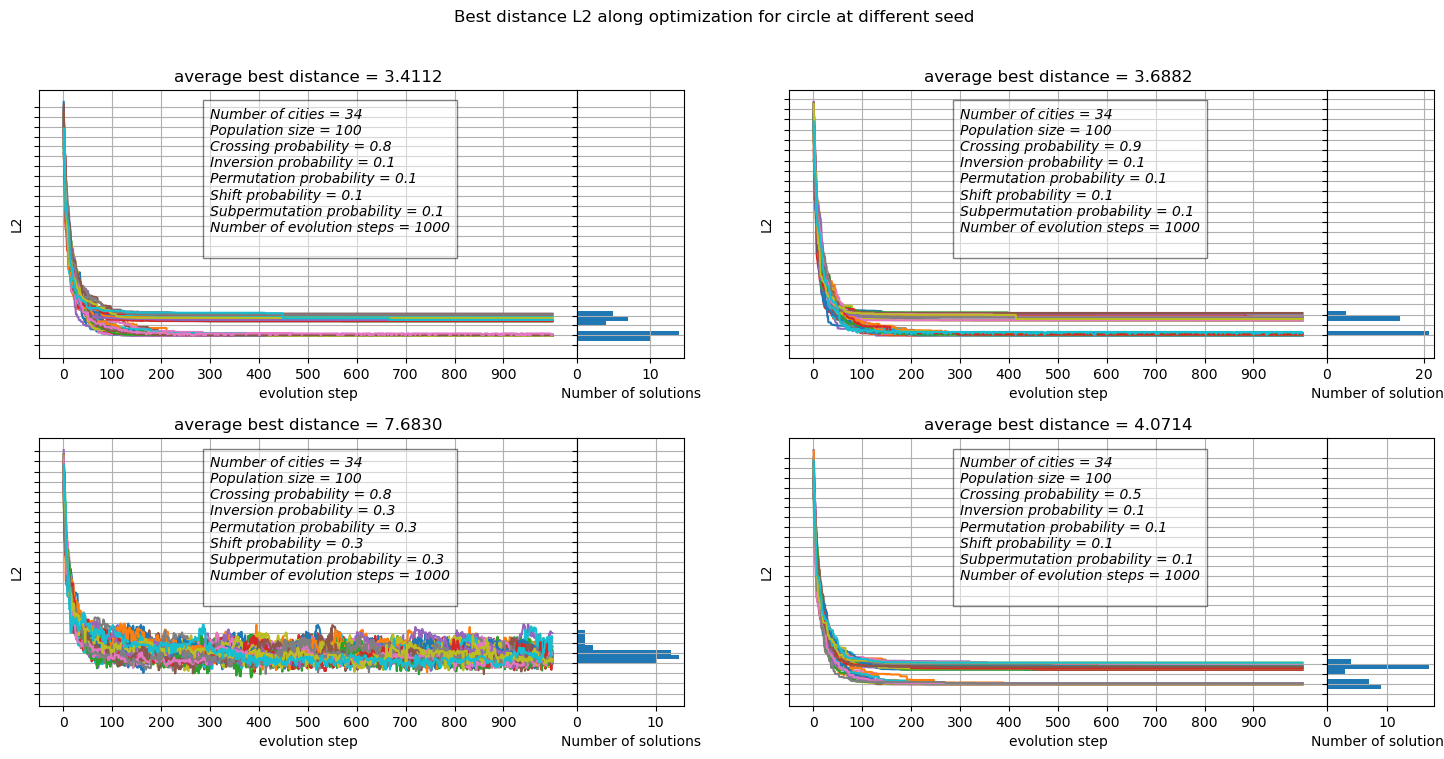

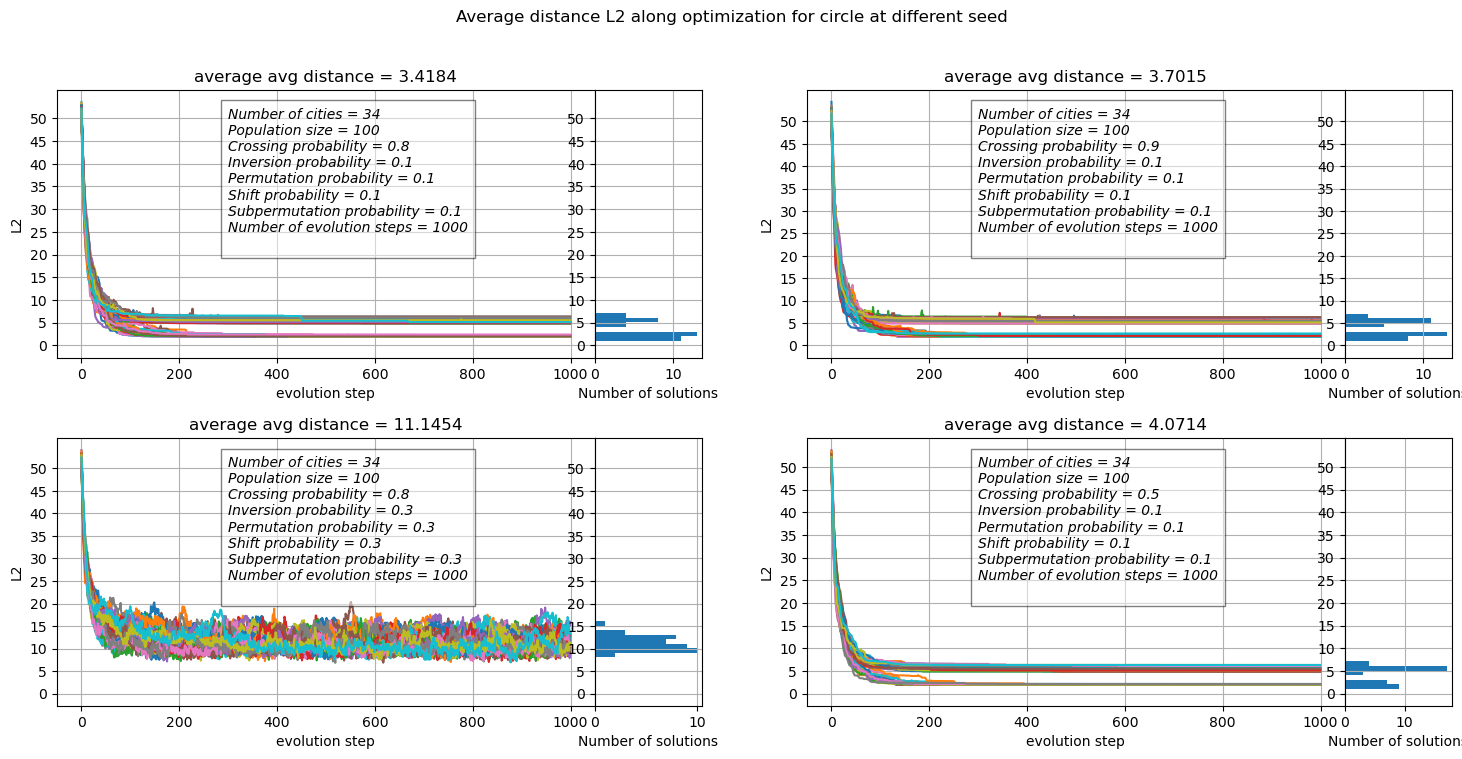

In [8]:
print_best_res(["OUTPUT/circle_setup1/", "OUTPUT/circle_setup2/", "OUTPUT/circle_setup3/", "OUTPUT/circle_setup4/"], 
    'Best distance L2 along optimization for circle at different seed'
)
print_avg_res(
    ["OUTPUT/circle_setup1/", "OUTPUT/circle_setup2/","OUTPUT/circle_setup3/","OUTPUT/circle_setup4/"],
    'Average distance L2 along optimization for circle at different seed'
    )

The best run for the circle case is the first configuration with 
- crossing probability = 0.8
- mutations probability = 0.1

which has a mean best cost of 3.4112

### Cities inside a square

/tmp/ipykernel_4991/2799982021.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


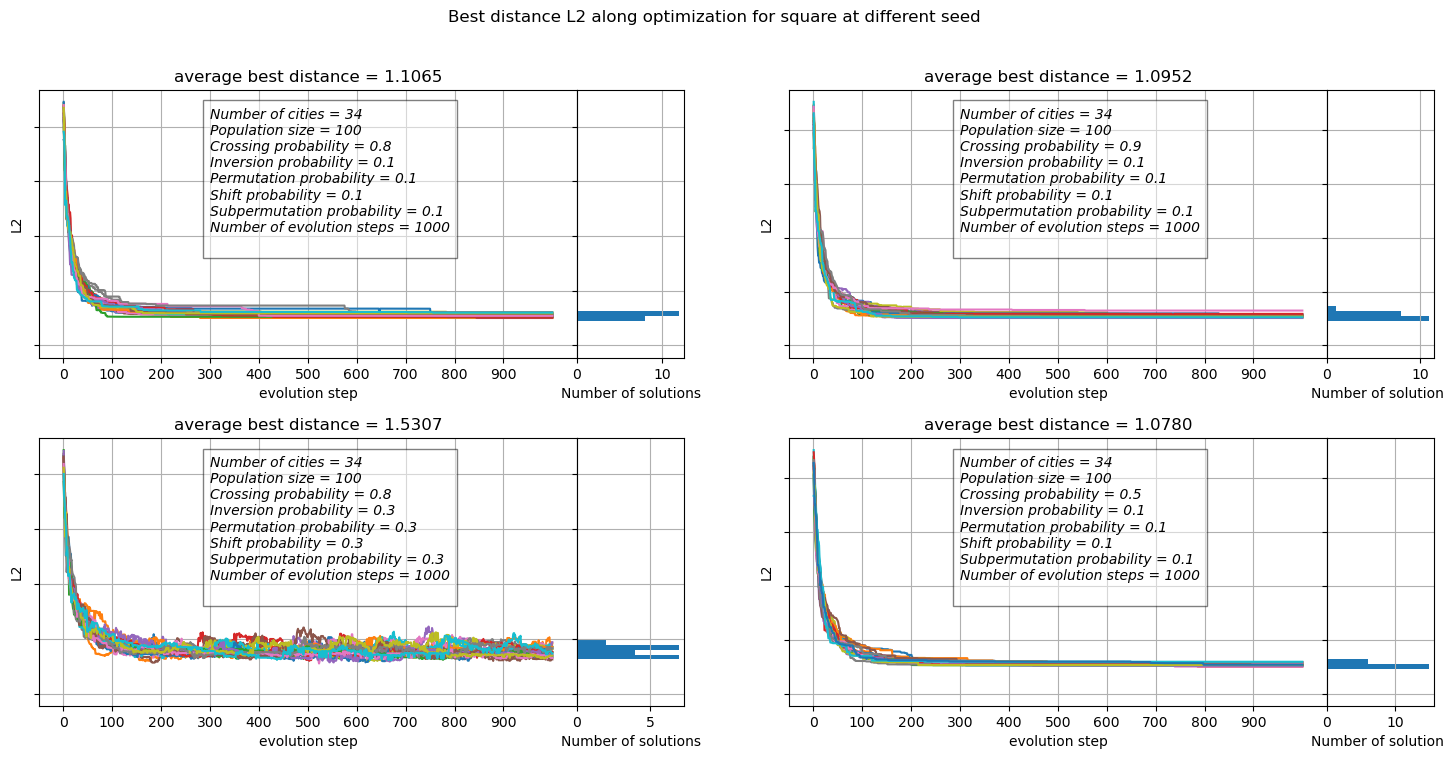

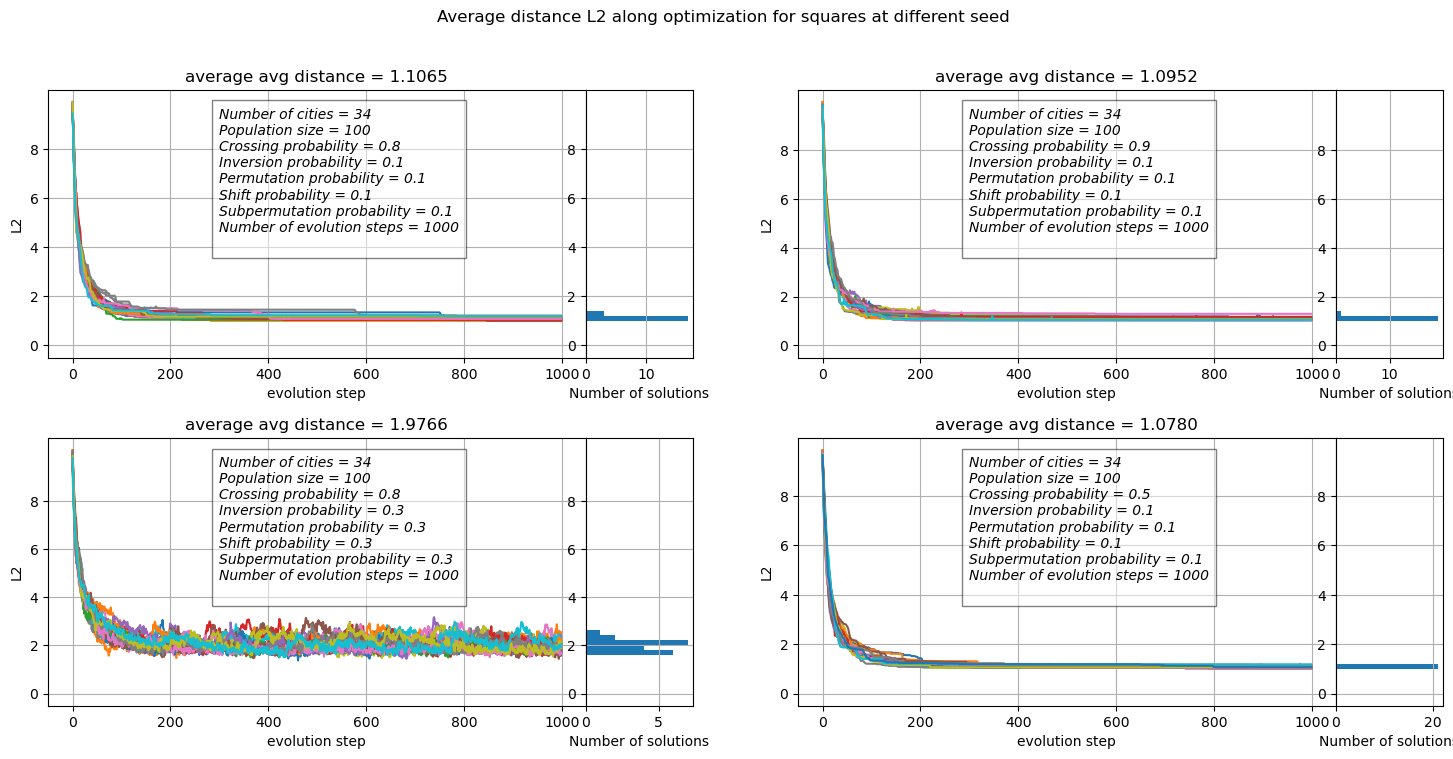

In [9]:
print_best_res(["OUTPUT/square_setup1/", "OUTPUT/square_setup2/", "OUTPUT/square_setup3/", "OUTPUT/square_setup4/"], 
    'Best distance L2 along optimization for square at different seed',
    coordfile='coord_SQUARE_34cities.dat'
)
print_avg_res(
    ["OUTPUT/square_setup1/", "OUTPUT/square_setup2/", "OUTPUT/square_setup3/","OUTPUT/square_setup4/"],
    'Average distance L2 along optimization for squares at different seed',
    coordfile='coord_SQUARE_34cities.dat'

    )

For the square we can see that the the third setup it's the best:
- Crossing probability = 0.5
- every mutation probability = 0.1

This setup lead to a mean (on the 20 runs) cost of the best solution of 1.0780

### Local minimum
Below are shown some realization of the optimal solution finded by the GA with the corresponding best and average history along optimization. I choosed some of the not-optimal realization to show that sometimes the algorithm can stuck in a local minimum.

/tmp/ipykernel_4991/1816733751.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


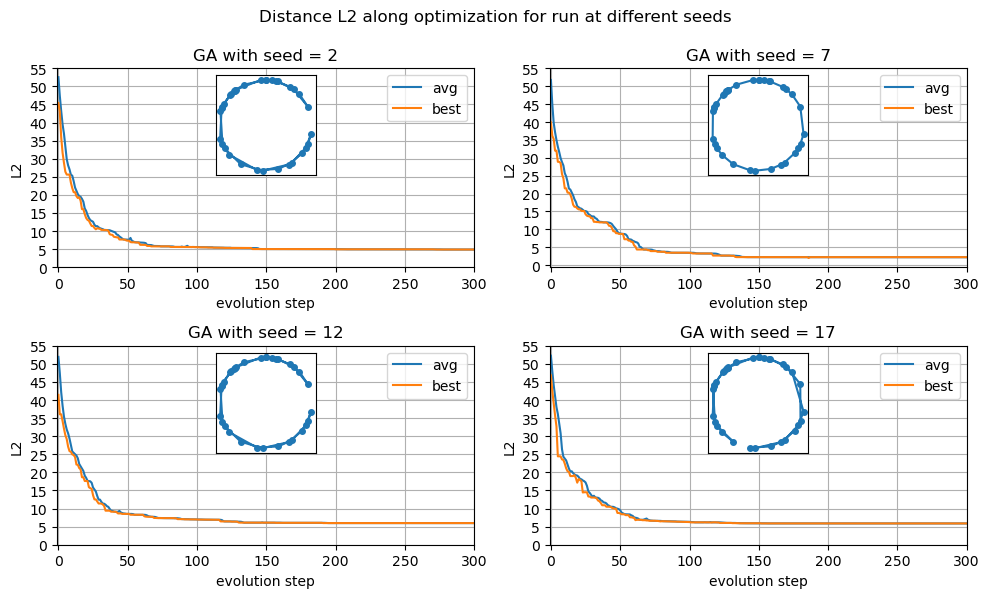

In [10]:
Nseed=20

n=2
fig, ax = plt.subplots(Nseed//(5*n), n, figsize=(5*n, 3*n))
fig.suptitle('Distance L2 along optimization for run at different seeds', y=0.99)
data_dir = "OUTPUT/circle_setup1/"


for ind, seed in enumerate(range(2,21, 5)):
    ax[ind//n, ind%n].set_title(f'GA with seed = {seed}')
    df_avg = pd.read_csv(data_dir+f'avg_circle_seed{seed}.dat', names=['avg'], skiprows=1)
    ax[ind//n, ind%n].plot(df_avg.index, df_avg['avg'], '-', label = f"avg") 

    df_best = pd.read_csv(data_dir+f'best_sol_circle_seed{seed}.dat', names=[f'city{k}' for k in range(35)]+['dist'], skiprows=1)
    ax[ind//n, ind%n].plot(df_best.index, df_best['dist'], '-', label = f"best") 

    ax[ind//n, ind%n].set_yticks(range(0, 60, 5), range(0, 60, 5))
    ax[ind//n, ind%n].grid()
    ax[ind//n, ind%n].legend()
    ax[ind//n, ind%n].set_xlabel('evolution step')
    ax[ind//n, ind%n].set_ylabel('L2')
    
    ax[ind//n, ind%n].set_xlim([-1, 300])
   
    sub_ax = inset_axes(
        parent_axes=ax[ind//n, ind%n],
        width=1,#"40%",
        height=1,#"40%",
        loc='upper center',
        borderpad=0.5  # padding between parent and inset axes
    )

    x=np.array([circle_coord.iloc[int(k)-1].x for k in df_best.iloc[len(df_best)-1][:-1].array])
    y=np.array([circle_coord.iloc[int(k)-1].y for k in df_best.iloc[len(df_best)-1][:-1].array])

    sub_ax.plot(x, y, '-o', ms=4)
    sub_ax.get_xaxis().set_visible(False)
    sub_ax.get_yaxis().set_visible(False)
plt.savefig(data_dir+'seed_distances.png', dpi=300)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4991/1868392082.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


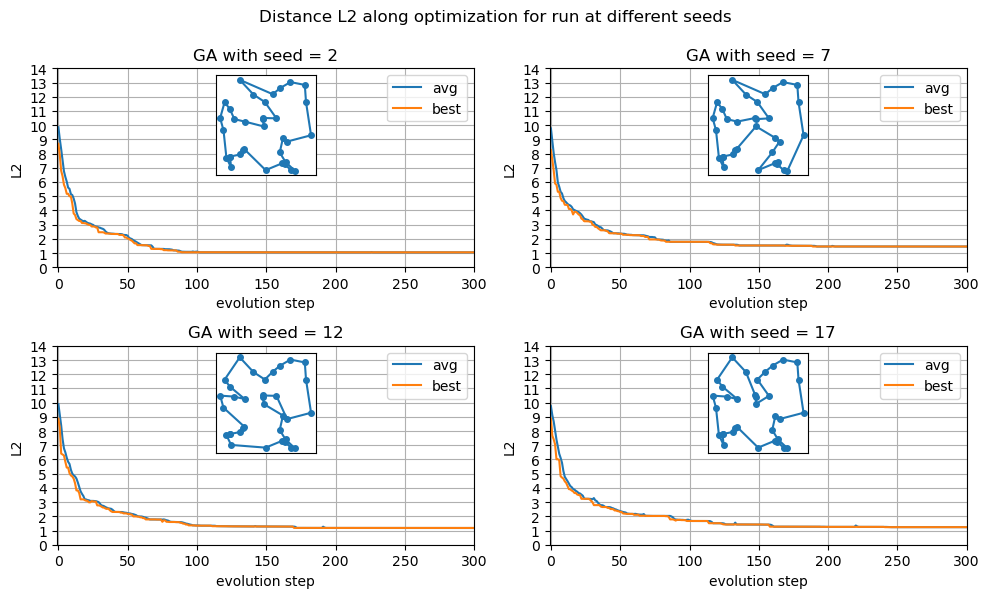

In [11]:
Nseed=20

n=2
fig, ax = plt.subplots(Nseed//(5*n), n, figsize=(5*n, 3*n))
fig.suptitle('Distance L2 along optimization for run at different seeds', y=0.99)
data_dir = "OUTPUT/square_setup1/"


for ind, seed in enumerate(range(2,21, 5)):
    ax[ind//n, ind%n].set_title(f'GA with seed = {seed}')
    df_avg = pd.read_csv(data_dir+f'avg_square_seed{seed}.dat', names=['avg'], skiprows=1)
    ax[ind//n, ind%n].plot(df_avg.index, df_avg['avg'], '-', label = f"avg") 

    df_best = pd.read_csv(data_dir+f'best_sol_square_seed{seed}.dat', names=[f'city{k}' for k in range(35)]+['dist'], skiprows=1)
    ax[ind//n, ind%n].plot(df_best.index, df_best['dist'], '-', label = f"best") 

    ax[ind//n, ind%n].set_yticks(range(0, 15), range(0, 15))
    ax[ind//n, ind%n].grid()
    ax[ind//n, ind%n].legend()
    ax[ind//n, ind%n].set_xlim([-1, 300])
    ax[ind//n, ind%n].set_xlabel('evolution step')
    ax[ind//n, ind%n].set_ylabel('L2')

    sub_ax = inset_axes(
        parent_axes=ax[ind//n, ind%n],
        width=1,#"40%",
        height=1,#"40%",
        loc='upper center',
        borderpad=0.5  # padding between parent and inset axes
    )

    x=np.array([square_coord.iloc[int(k)-1].x for k in df_best.iloc[len(df_best)-1][:-1].array])
    y=np.array([square_coord.iloc[int(k)-1].y for k in df_best.iloc[len(df_best)-1][:-1].array])

    sub_ax.plot(x, y, '-o', ms=4)
    sub_ax.get_xaxis().set_visible(False)
    sub_ax.get_yaxis().set_visible(False)
plt.savefig(data_dir+'seed_distances.png', dpi=300)
plt.tight_layout()
plt.show()

To visualize the behaviour of the GA during the optimization i created some gifs using the code i implemented [here](animation.py).


In the case of the run generated with seed = 6 on the cities disposed along a circle it's visible that the GA was stucked in a local minimum and didn't reach the optimal solution



Circle seed = 1             |  Circle seed = 2
:-------------------------:|:-------------------------:
![SegmentLocal](OUTPUT/gifs/animation_circle_seed1.gif "segment") | ![SegmentLocal](OUTPUT/gifs/animation_circle_seed6.gif "segment")


Square seed = 1             |  Square seed = 2
:-------------------------:|:-------------------------:
![SegmentLocal](OUTPUT/gifs/animation_square_seed1.gif "segment") | ![SegmentLocal](OUTPUT/gifs/animation_square_seed6.gif "segment")
